Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.


# Solución de la ecuación de calor usando un esquema explícito

Queremos resolver la ecuación

$$\frac{\partial u}{\partial t} = \alpha\nabla^2 u + q \quad \forall x\in(0, 1)\, , \forall t \in (0, t_\max)$$

con $u(0, t) = 0$ y $u(1, t)=0$ como condiciones de frontera. Adicionalmente, tenemos
la siguiente condición inicial

$$u(x, 0) = u_0(x)\, .$$

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from diferencias import resolver_explicito

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

## Simulación

A continuación definimos los parámetros para la simulación.
Note que se puede cambiar la difusividad térmica ($\alpha$).

In [5]:
niter = 10000
nx = 200
alpha = 1.0
fuente = lambda x: 0

x = np.linspace(0, 1, nx)
np.random.seed(201)
u_ini = np.sin(np.pi * x)
u_a = 0.0
u_b = 0.0
u_ini[0] = u_a
u_ini[-1] = u_b
k_iter = 0.4
dx = x[1] - x[0]
dt = k_iter * dx**2/alpha
t = np.linspace(0, niter*dt, niter)

In [6]:
U = resolver_explicito(niter, u_ini, alpha, dt, x, fuente)

## Visualización

In [7]:
T, X = np.meshgrid(t, x)

Text(0, 0.5, 'Posición')

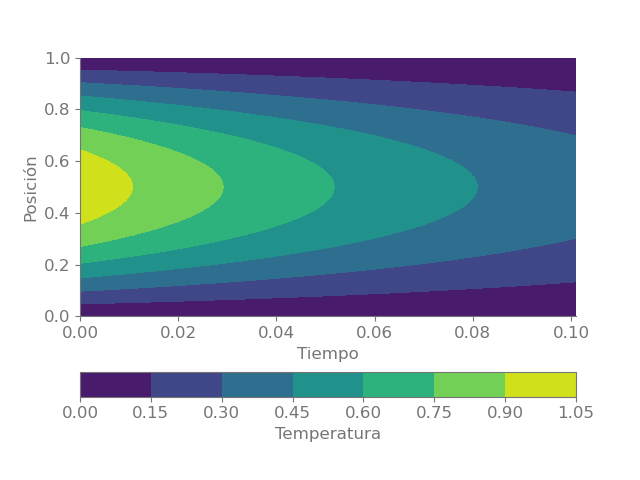

In [8]:
plt.figure()
plt.contourf(T, X, U.T)
plt.colorbar(orientation="horizontal", label="Temperatura")
plt.xlabel("Tiempo")
plt.ylabel("Posición")

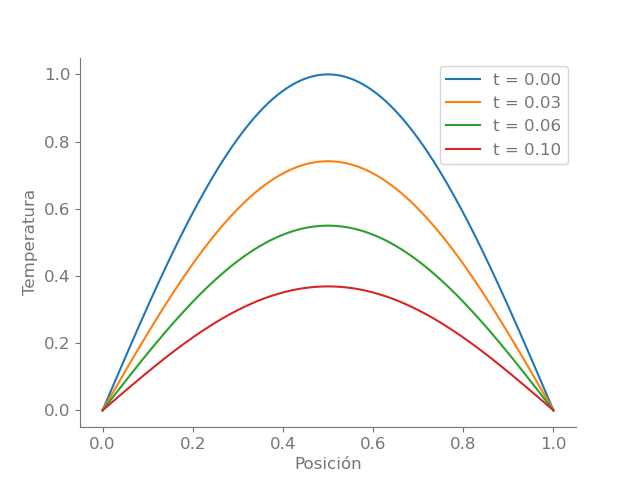

In [18]:
plt.figure()
plt.plot(x, U[0, :], label="t = 0.00")
plt.plot(x, U[3000, :], label="t = %.2f" % t[3000])
plt.plot(x, U[6000, :], label="t = %.2f" % t[6000])
plt.plot(x, U[-1, :], label="t = %.2f" % t[-1])
plt.xlabel("Posición")
plt.ylabel("Temperatura")
plt.legend()

Text(0, 0.5, 'Temperatura')

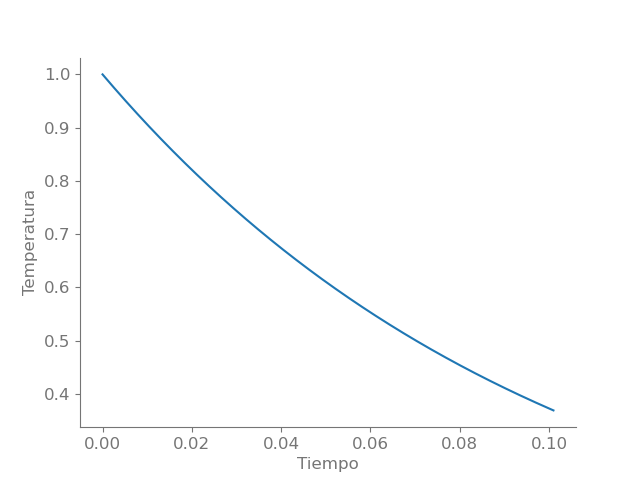

In [22]:
plt.figure()
plt.plot(t, U[:, 100])
plt.xlabel("Tiempo")
plt.ylabel("Temperatura")